# Imports

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import geopandas as gpd
import os
import mycolorpy.colorlist as mcp  # for colormap generation

# Define country and parameters

In [27]:
# Select target country
country = 'Chile'

# Set country-specific parameters: ISO codes and buffer size (in meters)
if country == 'Argentina':
    country_short = 'ARG'   # ISO 3-letter code
    country_code = 'AR'     # ISO 2-letter code
elif country == 'Chile':
    country_short = 'CHL'
    country_code = 'CL'
elif country == 'Colombia':
    country_short = 'COL'
    country_code = 'CO'
# Uncomment the following if Mexico is to be included in the analysis
# elif country == 'Mexico':
#     country_short = 'MEX'
#     country_code = 'MX'

# Set working directory

In [28]:
# Define working directory path
wd = (
#     '/your/path/to/working/directory/'
    '/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid'
)

# Load population and mobility grids, create buffered mobility cells
and quick graphic test of all grids

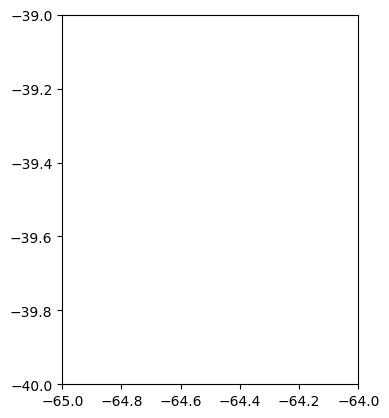

In [29]:
# Load population grid shapefile and project to WGS84 (EPSG:4326)
grid_popcell = gpd.read_file(
    f"{wd}/data/inputs/grids/Grid_{country}_FB_pop/Grid_{country}.shp"
).to_crs("EPSG:4326")

# Load mobility grid shapefile and project to WGS84 (EPSG:4326)
grid_movcell = gpd.read_file(
    f"{wd}/data/inputs/grids/Grid_{country}_FB_mov/Grid_{country}.shp"
).to_crs("EPSG:4326")

# Estimate buffer radius as 20% of the square root of the area of a typical (cell at index 2500), in meters
meters = 0.2 * np.sqrt(
    grid_popcell.to_crs("EPSG:3857").loc[2500, "geometry"].area
)

# Create a buffered version of the mobility grid using the estimated radius,
# reprojected to WGS84
grid_movcell_buff = gpd.GeoDataFrame(
    {
        "FID": grid_movcell["FID"],
        "geometry": grid_movcell.to_crs("EPSG:3857")
        .buffer(meters)
        .to_crs("EPSG:4326")
    }
)

# Quick graphic test of the above: visualise population grid, mobility grid, and mobility buffer

fig, ax = plt.subplots()

# Plot population grid with blue semi-transparent fill
grid_popcell.plot(
    ax=ax, edgecolor='white', facecolor='blue', alpha=0.3, zorder=1
)

# Plot mobility grid with red edges and no fill
grid_movcell.plot(
    ax=ax, edgecolor='red', facecolor='None', alpha=1, zorder=2
)

# Plot buffered mobility grid with blue edges and no fill
grid_movcell_buff.plot(
    ax=ax, edgecolor='blue', facecolor='None', alpha=1, zorder=3
)

# Optional: restrict plot extent to a specific bounding box
ax.set_xlim([-65, -64])
ax.set_ylim([-40, -39])

plt.show()

# Join buffered mobility cells to population grid to create lookup

In [30]:
# Spatial join using buffered mobility cells: include population cells within the buffer
gdf_sjoin = gpd.sjoin(
    grid_movcell_buff,
    grid_popcell,
    how='left',
    predicate='contains',
    lsuffix='mov',
    rsuffix='pop'
).drop(['index_pop'], axis=1)

# Save the buffer-based join result to GeoPackage
# gdf_sjoin.to_file(f"{wd}/data/inputs/grids/Grid_{country}_lookup_mov_to_pop.gpkg")

# Aggregate imputed population data from pop to mov grid cells

In [31]:
# Create a copy of the mobility grid for imputing population data
grid_pop_imput_movcell = grid_movcell.copy()

# Initialize columns for each day of the week (0–6) with NaN
for i in range(7):
    grid_pop_imput_movcell[str(i)] = [np.nan] * len(grid_pop_imput_movcell)

# Load population cell data with built-up-constrained imputed population values per weekday
grid_pop_imput_popcell = gpd.read_file(
    f"{wd}/data/outputs/{country_short}/grids-with-data/popcell-baseline-imput-pop-builtup/popcell-baseline-imput-pop-builtup.gpkg"
)
if 'has_builtup' not in grid_pop_imput_popcell.columns:
    grid_pop_imput_popcell['has_builtup'] = 0

# Initialise built-up flag column on the mobility grid
grid_pop_imput_movcell['has_builtup'] = 0

# For each mobility cell, sum the weekday populations of the population cells it contains
for i in range(len(grid_pop_imput_movcell)):
    
    # Get indices of population cells within the current mobility cell
    FIDs_pop = np.array(gdf_sjoin[gdf_sjoin['FID_mov'] == i]['FID_pop'])
    
    # Select those population cells
    gdf_movcell = grid_pop_imput_popcell.iloc[FIDs_pop]
    
    # Sum population for each day of the week
    for wday in range(7):
        pops_movcell = np.array(gdf_movcell[str(wday)])
        pops_movcell = pops_movcell[~np.isnan(pops_movcell)]
        
        # Assign sum if values exist, else keep NaN
        grid_pop_imput_movcell.loc[i, str(wday)] = (
            np.sum(pops_movcell) if len(pops_movcell) > 0 else np.nan
        ) 

    builtup_values = np.array(gdf_movcell['has_builtup'])
    builtup_values = builtup_values[~np.isnan(builtup_values)]
    grid_pop_imput_movcell.loc[i, 'has_builtup'] = (
        int(np.any(builtup_values > 0)) if len(builtup_values) > 0 else 0
    )
        
output_path = wd + '/data/outputs/' + country_short + '/grids-with-data/movcell-baseline-imput-pop-builtup/movcell-baseline-imput-pop-builtup.gpkg'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
grid_pop_imput_movcell.to_file(output_path)

# Below, quick visualisation, not necessary for analysis, just for checks

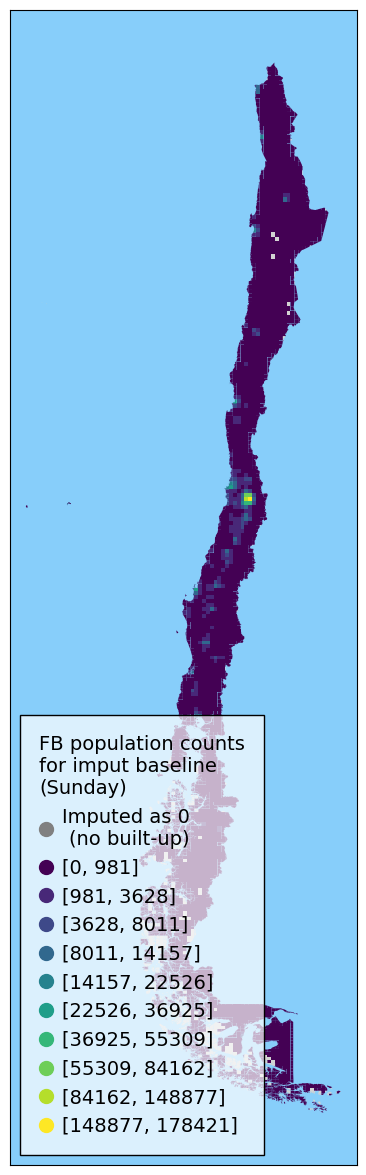

In [32]:
fig, ax = plt.subplots(figsize=(15, 15))

# Set background color to light sky blue
ax.set_facecolor('lightskyblue')

# Separate movement cells with zero population and no built-up area so they can be shown in gray.
grid_pop_imput_movcell_positive = grid_pop_imput_movcell[
    ~((grid_pop_imput_movcell['6'] == 0) & (grid_pop_imput_movcell['has_builtup'] == 0))
].reset_index(drop=True)
grid_pop_imput_movcell_zero_builtup = grid_pop_imput_movcell[
    (grid_pop_imput_movcell['6'] == 0) & (grid_pop_imput_movcell['has_builtup'] == 0)
].reset_index(drop=True)

# Plot population data for weekday 6 with viridis colormap and natural breaks classification
grid_pop_imput_movcell_positive.plot(
    column='6',
    cmap='viridis',
    scheme='natural_breaks',
    k=10,
    legend=True,
    ax=ax
)
grid_pop_imput_movcell_zero_builtup.plot(color='lightgray', zorder=3, ax=ax)

# Remove axis ticks and labels
ax.tick_params(axis='both', which='both', width=0, length=0, labelleft=False, labelbottom=False)

# Extract legend labels and parse upper bounds for intervals
labels = [t.get_text() for t in ax.get_legend().get_texts()]

upper = []
for i in range(len(labels)):
    a = labels[i].split(',')[1]
    b = []
    for e in a:
        if e.isdigit() or e == '.':
            b.append(e)
    upper.append(float(''.join(b)))
upper[-1] += 0.005  # Slightly increase last upper bound

# Build custom interval labels
custom_labels = ['Imputed as 0\n(no built-up)']
custom_labels.append('[0, ' + str(int(upper[0])) + ']')
for i in range(len(upper) - 1):
    custom_labels.append('[' + str(int(upper[i])) + ', ' + str(int(upper[i+1])) + ']')

# Generate matching colors from viridis colormap
colors = ['gray'] + mcp.gen_color(cmap='viridis', n=10)

# Create legend elements with colored markers and custom labels
legend_elements = [
    Line2D([0], [0], lw=0, color=colors[i], marker='o', markersize=10, label=custom_labels[i])
    for i in range(len(colors))
]
legend = ax.legend(
    handles=legend_elements,
    handlelength=0,
    fontsize=14,
    shadow=False,
    fancybox=False,
    loc='lower left',
    ncol=1,
    columnspacing=0.1,
    borderpad=1,
    title='FB population counts\nfor imput baseline\n(Sunday)',
)
for t in legend.get_texts():
    t.set_ha('right')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)
legend.get_frame().set_alpha(None)
legend.get_frame().set_facecolor((1, 1, 1, 0.7))
legend.get_title().set_fontsize('14')

# Optionally add a north arrow image (commented out)
# im = plt.imread(wd + '/data/inputs/boundaries/north-arrow.png')
# newax = fig.add_axes([0.355, 0.78, 0.04, 0.04], zorder=1)
# newax.tick_params(axis='both', which='both', labelbottom=False, labelleft=False, width=0, length=0)
# newax.set_facecolor('None')
# plt.setp(newax.spines.values(), linewidth=0)
# newax.imshow(im)

plt.show()
